## Haase 2023 site-level trends

In [ ]:
print("[[step]] n_data start 1/7 ▶ Haase 2023 site-level trends", flush=True)

import os, json, warnings, pathlib, sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_cluster
from scipy import stats

# Ensure artifact directory exists
ARTIFACT_DIR = pathlib.Path("./artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Load the main dataframe
data_path = pathlib.Path("data/Haase2023_freshwater_siteData.csv")
df_n_data = pd.read_csv(data_path)

# Basic metrics
metrics = {}
metrics["n_data::rows"] = int(df_n_data.shape[0])
metrics["n_data::columns"] = int(df_n_data.shape[1])

print("[[step]] n_data done 1/7 ✓ Haase 2023 site-level trends", flush=True)

## Audit Site-Level Input

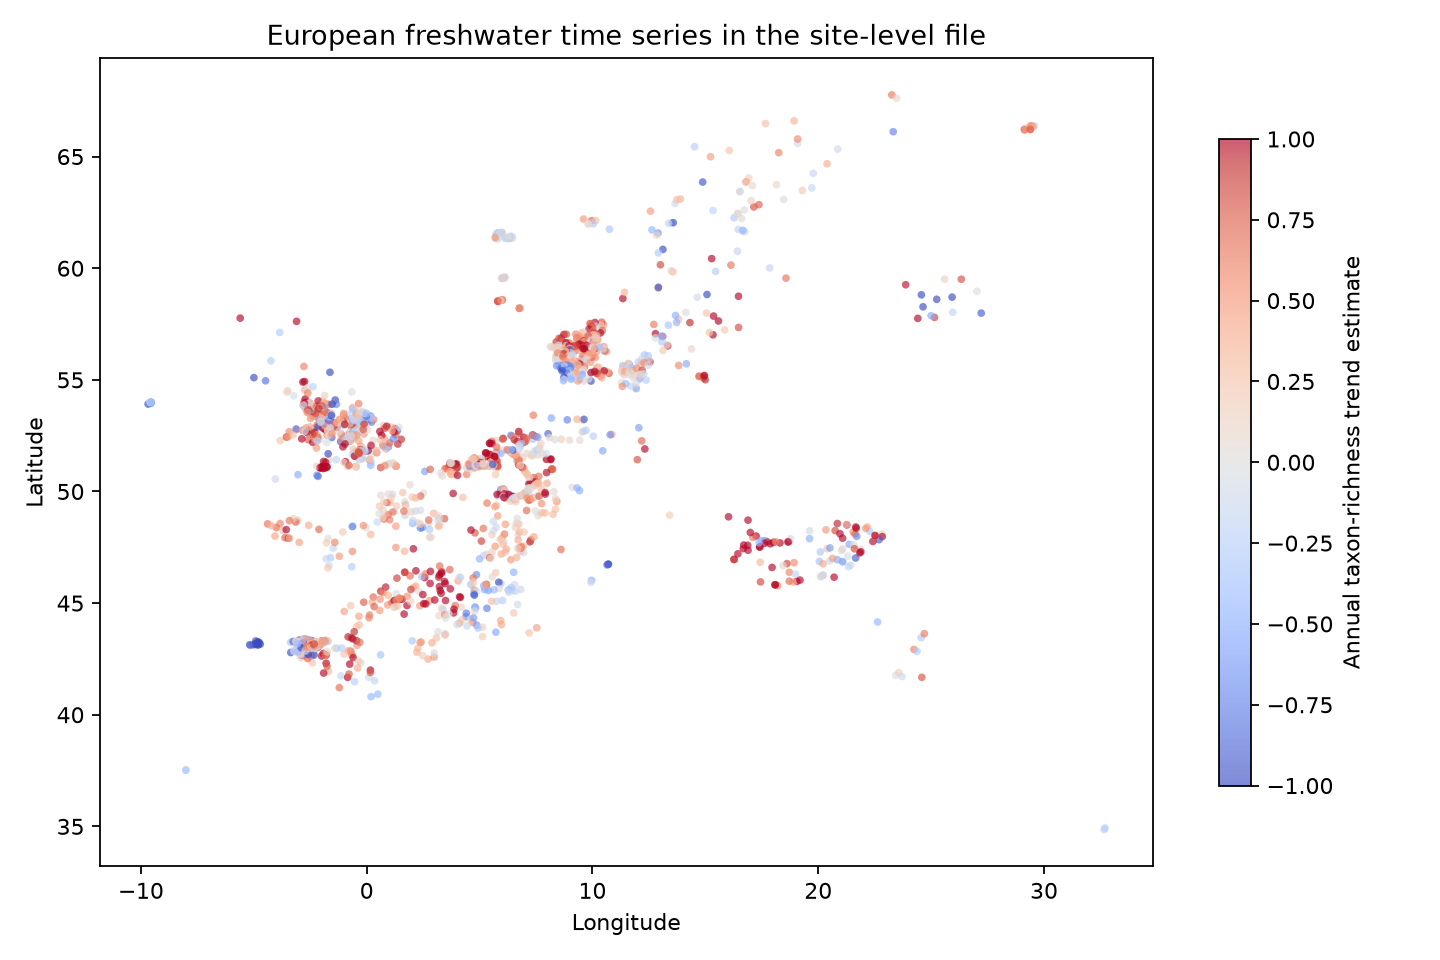

In [ ]:
from pathlib import Path as _AlkNodePath
_alk_node_id = 'haase_audit'
_alk_metrics_before = dict(globals().get("METRICS", {}))
_alk_artifact_dir = _AlkNodePath("artifacts")
_alk_artifact_dir.mkdir(parents=True, exist_ok=True)
_alk_files_before = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}

print("[[step]] haase_audit start 2/7 ▶ Audit Site-Level Input", flush=True)
print("[[title]] haase_audit Audit Site-Level Input", flush=True)

site_data = df_n_data.copy()
required = {
    "site_id", "study_id", "Country", "Starting_year", "Ending_year",
    "Longitude_X", "Latitude_Y", "spp_richness", "abundance", "FRic", "FRed",
}
missing_required = sorted(required.difference(site_data.columns))
if missing_required:
    raise ValueError("missing required site-level columns: " + ", ".join(missing_required))

if site_data["site_id"].duplicated().any():
    raise ValueError("the site-level input contains duplicate site_id values")

trend_columns = [
    "spp_richness", "abundance", "spp_rich_rare", "shannonsH", "E10",
    "turnover", "FRic", "FDiv", "RaoQ", "FEve", "FRed", "F_to",
    "SppRich_nativeSpp", "alien_SppRich", "abund_nativeSpp", "alien_Abund",
    "EPT_Abund", "EPT_SppRich", "insect_Abund", "insect_SppRich",
]
available_trends = [c for c in trend_columns if c in site_data.columns]

audit_rows = [
    {"check": "rows", "value": int(len(site_data)), "meaning": "one row per site"},
    {"check": "unique_sites", "value": int(site_data["site_id"].nunique()), "meaning": "unique time series"},
    {"check": "studies", "value": int(site_data["study_id"].nunique()), "meaning": "independent source studies"},
    {"check": "countries", "value": int(site_data["Country"].nunique()), "meaning": "countries represented"},
    {"check": "first_year", "value": int(site_data["Starting_year"].min()), "meaning": "earliest series start"},
    {"check": "last_year", "value": int(site_data["Ending_year"].max()), "meaning": "latest series end"},
    {"check": "trend_columns", "value": int(len(available_trends)), "meaning": "precomputed annual trend estimates"},
]
audit_table = pd.DataFrame(audit_rows)
audit_table.to_csv(ARTIFACT_DIR / "haase_audit__dataset_audit.csv", index=False)

missing_table = pd.DataFrame({
    "column": available_trends,
    "missing": [int(site_data[c].isna().sum()) for c in available_trends],
})
missing_table["missing_share"] = missing_table["missing"] / len(site_data)
missing_table.to_csv(ARTIFACT_DIR / "haase_audit__trend_missingness.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    site_data["Longitude_X"], site_data["Latitude_Y"],
    c=site_data["spp_richness"], cmap="coolwarm", vmin=-1, vmax=1,
    s=12, alpha=0.65, linewidths=0,
)
ax.set(title="European freshwater time series in the site-level file",
       xlabel="Longitude", ylabel="Latitude")
bar = fig.colorbar(points, ax=ax, shrink=0.8)
bar.set_label("Annual taxon-richness trend estimate")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "haase_audit__site_map.png", dpi=160)
plt.close(fig)

metrics["haase_audit::sites"] = int(site_data["site_id"].nunique())
metrics["haase_audit::studies"] = int(site_data["study_id"].nunique())
metrics["haase_audit::countries"] = int(site_data["Country"].nunique())
metrics["haase_audit::first_year"] = int(site_data["Starting_year"].min())
metrics["haase_audit::last_year"] = int(site_data["Ending_year"].max())
df_haase_audit = site_data
print("[[step]] haase_audit done 2/7 ✓ Audit Site-Level Input", flush=True)


_alk_metrics = globals().setdefault("METRICS", {})
for _k, _v in list(_alk_metrics.items()):
    if (_k not in _alk_metrics_before or _alk_metrics_before[_k] != _v) and "::" not in str(_k):
        _alk_metrics[_alk_node_id + "::" + str(_k)] = _v
if "df" in globals() and hasattr(df, "shape"):
    _alk_metrics[_alk_node_id + "::output_rows"] = int(df.shape[0])
    _alk_metrics[_alk_node_id + "::output_columns"] = int(df.shape[1])
_alk_files_after = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}
_alk_changed_files = [
    _name for _name, _stamp in _alk_files_after.items()
    if _alk_files_before.get(_name) != _stamp
]
if not _alk_changed_files and "df" in globals() and hasattr(df, "head"):
    _alk_preview = _alk_artifact_dir / (_alk_node_id + "__result_preview.csv")
    df.head(200).to_csv(_alk_preview, index=False)
    _alk_changed_files = [_alk_preview.name]
_alk_ledger = _AlkNodePath("work/node_artifact_owners.tsv")
_alk_ledger.parent.mkdir(parents=True, exist_ok=True)
with _alk_ledger.open("a", encoding="utf-8") as _alk_owner_file:
    for _name in _alk_changed_files:
        if "__" not in _AlkNodePath(_name).stem and "\t" not in _name and "\n" not in _name:
            _alk_owner_file.write(_alk_node_id + "\t" + _name + "\n")

## Long-Term Trend Check

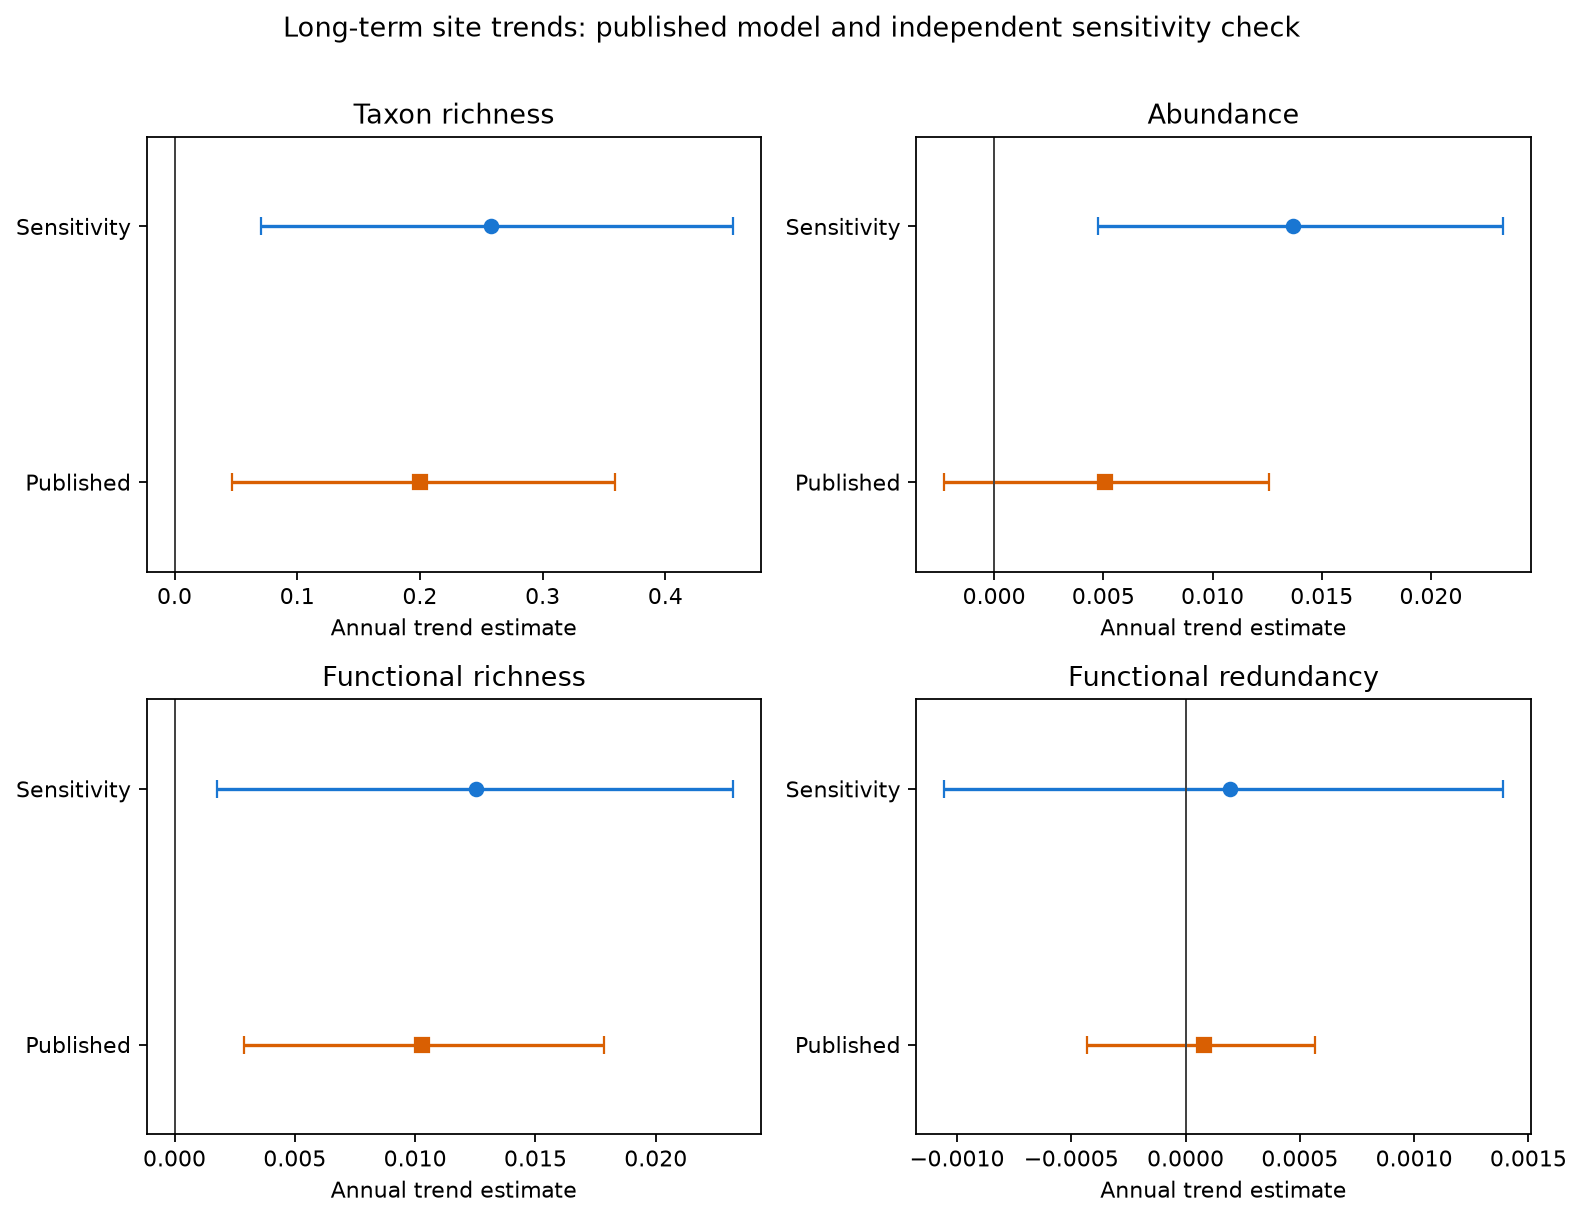

In [ ]:
from pathlib import Path as _AlkNodePath
_alk_node_id = 'haase_long_term'
_alk_metrics_before = dict(globals().get("METRICS", {}))
_alk_artifact_dir = _AlkNodePath("artifacts")
_alk_artifact_dir.mkdir(parents=True, exist_ok=True)
_alk_files_before = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}

print("[[step]] haase_long_term start 3/7 ▶ Long-Term Trend Check", flush=True)
print("[[title]] haase_long_term Long-Term Trend Check", flush=True)

analysis_specs = {
    "spp_richness": {
        "label": "Taxon richness", "paper_estimate": 0.200403514,
        "paper_low": 0.047120045, "paper_high": 0.359266640,
    },
    "abundance": {
        "label": "Abundance", "paper_estimate": 0.005070704,
        "paper_low": -0.002290450, "paper_high": 0.012590343,
    },
    "FRic": {
        "label": "Functional richness", "paper_estimate": 0.010303468,
        "paper_low": 0.002883881, "paper_high": 0.017838330,
    },
    "FRed": {
        "label": "Functional redundancy", "paper_estimate": 0.0000811,
        "paper_low": -0.000431128, "paper_high": 0.000566432,
    },
}

rng = np.random.default_rng(42)
summary_rows = []
for column, spec in analysis_specs.items():
    working = df_haase_audit[["study_id", column]].dropna()
    site_values = working[column].astype(float)
    study_means = working.groupby("study_id", observed=True)[column].mean()
    study_values = study_means.to_numpy(dtype=float)
    boot = np.empty(5000, dtype=float)
    for i in range(len(boot)):
        boot[i] = rng.choice(study_values, size=len(study_values), replace=True).mean()
    low, high = np.quantile(boot, [0.025, 0.975])
    summary_rows.append({
        "metric": column,
        "label": spec["label"],
        "sites": int(len(site_values)),
        "studies": int(len(study_values)),
        "site_mean": float(site_values.mean()),
        "site_median": float(site_values.median()),
        "positive_site_share": float((site_values > 0).mean()),
        "study_balanced_mean": float(study_values.mean()),
        "study_bootstrap_low_95": float(low),
        "study_bootstrap_high_95": float(high),
        "paper_posterior_estimate": spec["paper_estimate"],
        "paper_posterior_low_95": spec["paper_low"],
        "paper_posterior_high_95": spec["paper_high"],
        "paper_estimate_inside_sensitivity_interval": bool(low <= spec["paper_estimate"] <= high),
    })

trend_summary = pd.DataFrame(summary_rows)
trend_summary.to_csv(ARTIFACT_DIR / "haase_long_term__trend_comparison.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, row in zip(axes.flat, summary_rows):
    ax.errorbar(
        row["study_balanced_mean"], 1,
        xerr=[[row["study_balanced_mean"] - row["study_bootstrap_low_95"]],
              [row["study_bootstrap_high_95"] - row["study_balanced_mean"]]],
        fmt="o", color="#1976d2", capsize=4, label="Study-balanced sensitivity",
    )
    ax.errorbar(
        row["paper_posterior_estimate"], 0,
        xerr=[[row["paper_posterior_estimate"] - row["paper_posterior_low_95"]],
              [row["paper_posterior_high_95"] - row["paper_posterior_estimate"]]],
        fmt="s", color="#d95f02", capsize=4, label="Published Bayesian estimate",
    )
    ax.axvline(0, color="#444", linewidth=0.9)
    ax.set_yticks([0, 1], ["Published", "Sensitivity"])
    ax.set_ylim(-0.35, 1.35)
    ax.set_title(row["label"])
    ax.set_xlabel("Annual trend estimate")
fig.suptitle("Long-term site trends: published model and independent sensitivity check", y=1.01)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "haase_long_term__published_comparison.png", dpi=160, bbox_inches="tight")
plt.close(fig)

for row in summary_rows:
    key = row["metric"]
    metrics[f"haase_long_term::{key}_study_balanced_mean"] = float(row["study_balanced_mean"])
    metrics[f"haase_long_term::{key}_positive_site_share"] = float(row["positive_site_share"])
    metrics[f"haase_long_term::{key}_paper_inside_interval"] = int(row["paper_estimate_inside_sensitivity_interval"])
df_haase_long_term = df_haase_audit
print("[[step]] haase_long_term done 3/7 ✓ Long-Term Trend Check", flush=True)


_alk_metrics = globals().setdefault("METRICS", {})
for _k, _v in list(_alk_metrics.items()):
    if (_k not in _alk_metrics_before or _alk_metrics_before[_k] != _v) and "::" not in str(_k):
        _alk_metrics[_alk_node_id + "::" + str(_k)] = _v
if "df" in globals() and hasattr(df, "shape"):
    _alk_metrics[_alk_node_id + "::output_rows"] = int(df.shape[0])
    _alk_metrics[_alk_node_id + "::output_columns"] = int(df.shape[1])
_alk_files_after = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}
_alk_changed_files = [
    _name for _name, _stamp in _alk_files_after.items()
    if _alk_files_before.get(_name) != _stamp
]
if not _alk_changed_files and "df" in globals() and hasattr(df, "head"):
    _alk_preview = _alk_artifact_dir / (_alk_node_id + "__result_preview.csv")
    df.head(200).to_csv(_alk_preview, index=False)
    _alk_changed_files = [_alk_preview.name]
_alk_ledger = _AlkNodePath("work/node_artifact_owners.tsv")
_alk_ledger.parent.mkdir(parents=True, exist_ok=True)
with _alk_ledger.open("a", encoding="utf-8") as _alk_owner_file:
    for _name in _alk_changed_files:
        if "__" not in _AlkNodePath(_name).stem and "\t" not in _name and "\n" not in _name:
            _alk_owner_file.write(_alk_node_id + "\t" + _name + "\n")

## Site Trend Distributions

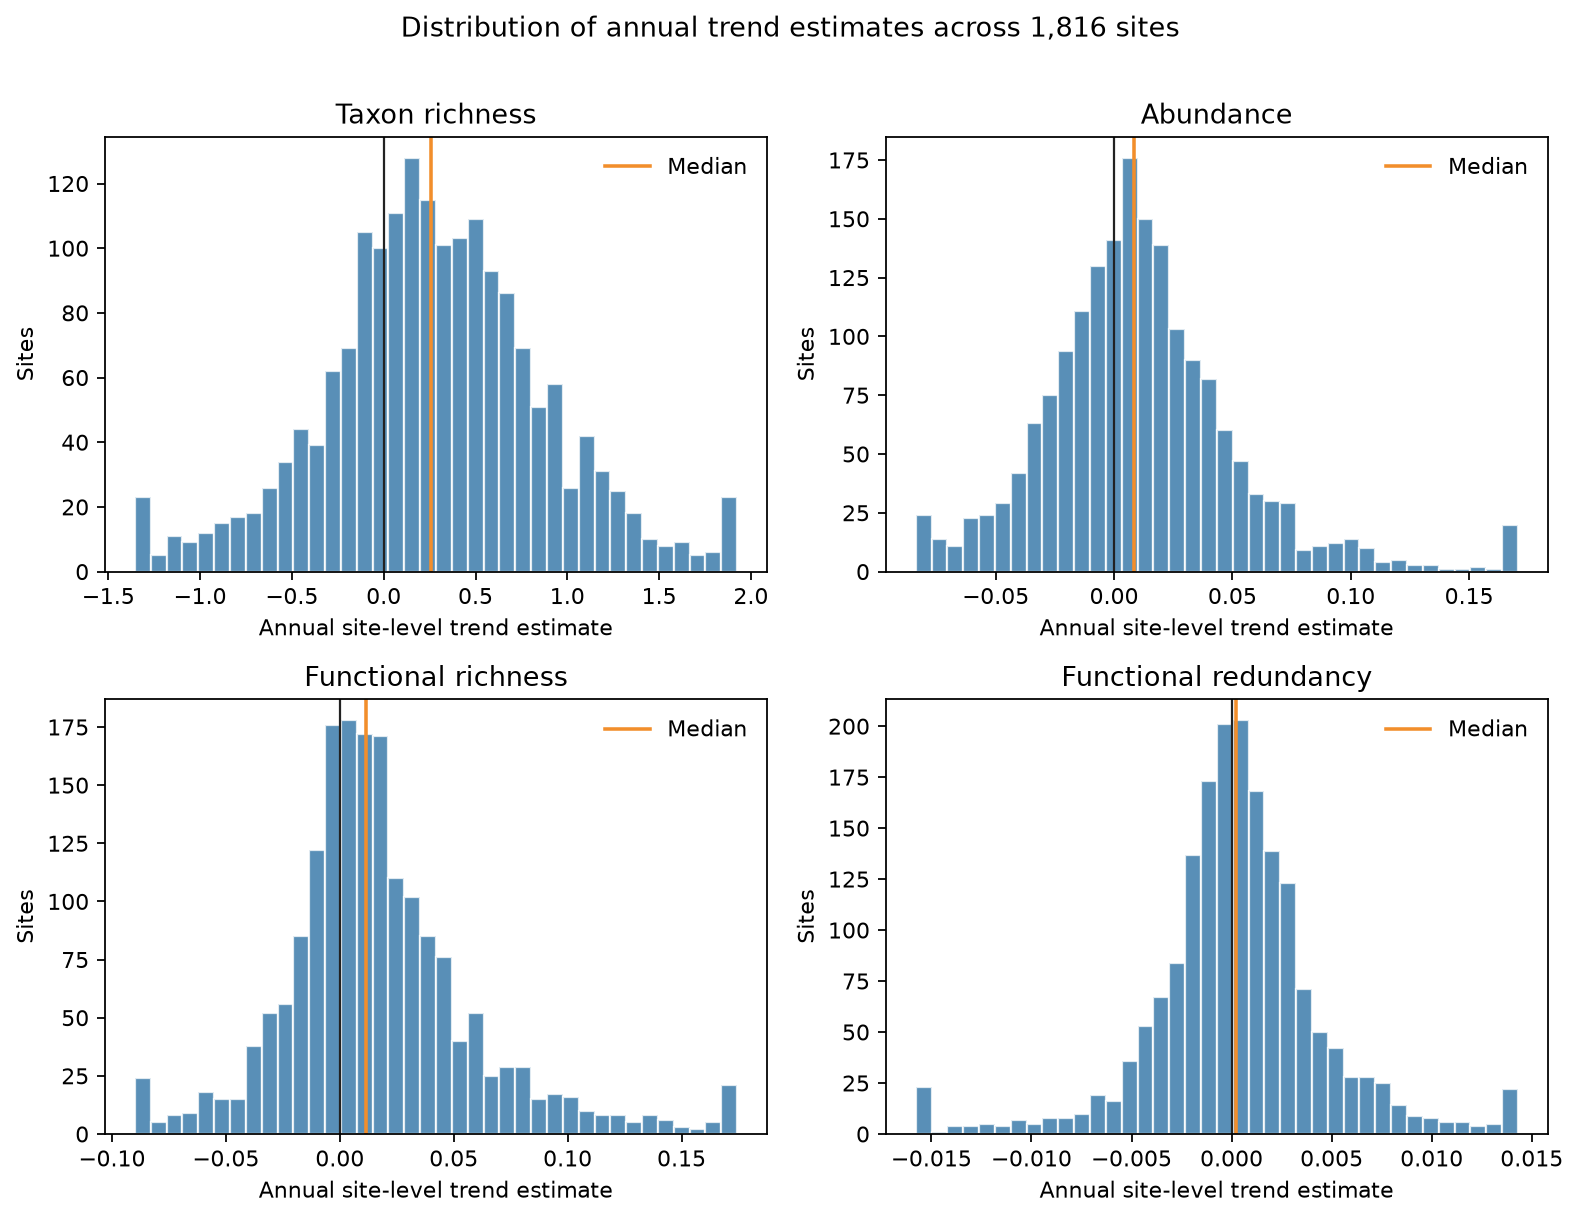

In [ ]:
from pathlib import Path as _AlkNodePath
_alk_node_id = 'haase_distribution'
_alk_metrics_before = dict(globals().get("METRICS", {}))
_alk_artifact_dir = _AlkNodePath("artifacts")
_alk_artifact_dir.mkdir(parents=True, exist_ok=True)
_alk_files_before = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}

print("[[step]] haase_distribution start 4/7 ▶ Site Trend Distributions", flush=True)
print("[[title]] haase_distribution Site Trend Distributions", flush=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
for ax, (column, spec) in zip(axes.flat, analysis_specs.items()):
    values = df_haase_long_term[column].dropna().astype(float)
    lo, hi = values.quantile([0.01, 0.99])
    shown = values.clip(lo, hi)
    ax.hist(shown, bins=38, color="#3577a8", alpha=0.82, edgecolor="white")
    ax.axvline(0, color="#222", linewidth=1.0)
    ax.axvline(values.median(), color="#f28e2b", linewidth=1.6, label="Median")
    ax.set_title(spec["label"])
    ax.set_xlabel("Annual site-level trend estimate")
    ax.set_ylabel("Sites")
    ax.legend(frameon=False)
fig.suptitle("Distribution of annual trend estimates across 1,816 sites", y=1.01)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "haase_distribution__site_trends.png", dpi=160, bbox_inches="tight")
plt.close(fig)

distribution_summary = trend_summary[[
    "metric", "sites", "site_mean", "site_median", "positive_site_share",
]].copy()
distribution_summary.to_csv(ARTIFACT_DIR / "haase_distribution__summary.csv", index=False)
metrics["haase_distribution::metrics_plotted"] = int(len(analysis_specs))
df_haase_distribution = df_haase_long_term
print("[[step]] haase_distribution done 4/7 ✓ Site Trend Distributions", flush=True)


_alk_metrics = globals().setdefault("METRICS", {})
for _k, _v in list(_alk_metrics.items()):
    if (_k not in _alk_metrics_before or _alk_metrics_before[_k] != _v) and "::" not in str(_k):
        _alk_metrics[_alk_node_id + "::" + str(_k)] = _v
if "df" in globals() and hasattr(df, "shape"):
    _alk_metrics[_alk_node_id + "::output_rows"] = int(df.shape[0])
    _alk_metrics[_alk_node_id + "::output_columns"] = int(df.shape[1])
_alk_files_after = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}
_alk_changed_files = [
    _name for _name, _stamp in _alk_files_after.items()
    if _alk_files_before.get(_name) != _stamp
]
if not _alk_changed_files and "df" in globals() and hasattr(df, "head"):
    _alk_preview = _alk_artifact_dir / (_alk_node_id + "__result_preview.csv")
    df.head(200).to_csv(_alk_preview, index=False)
    _alk_changed_files = [_alk_preview.name]
_alk_ledger = _AlkNodePath("work/node_artifact_owners.tsv")
_alk_ledger.parent.mkdir(parents=True, exist_ok=True)
with _alk_ledger.open("a", encoding="utf-8") as _alk_owner_file:
    for _name in _alk_changed_files:
        if "__" not in _AlkNodePath(_name).stem and "\t" not in _name and "\n" not in _name:
            _alk_owner_file.write(_alk_node_id + "\t" + _name + "\n")

## Driver Sensitivity Check

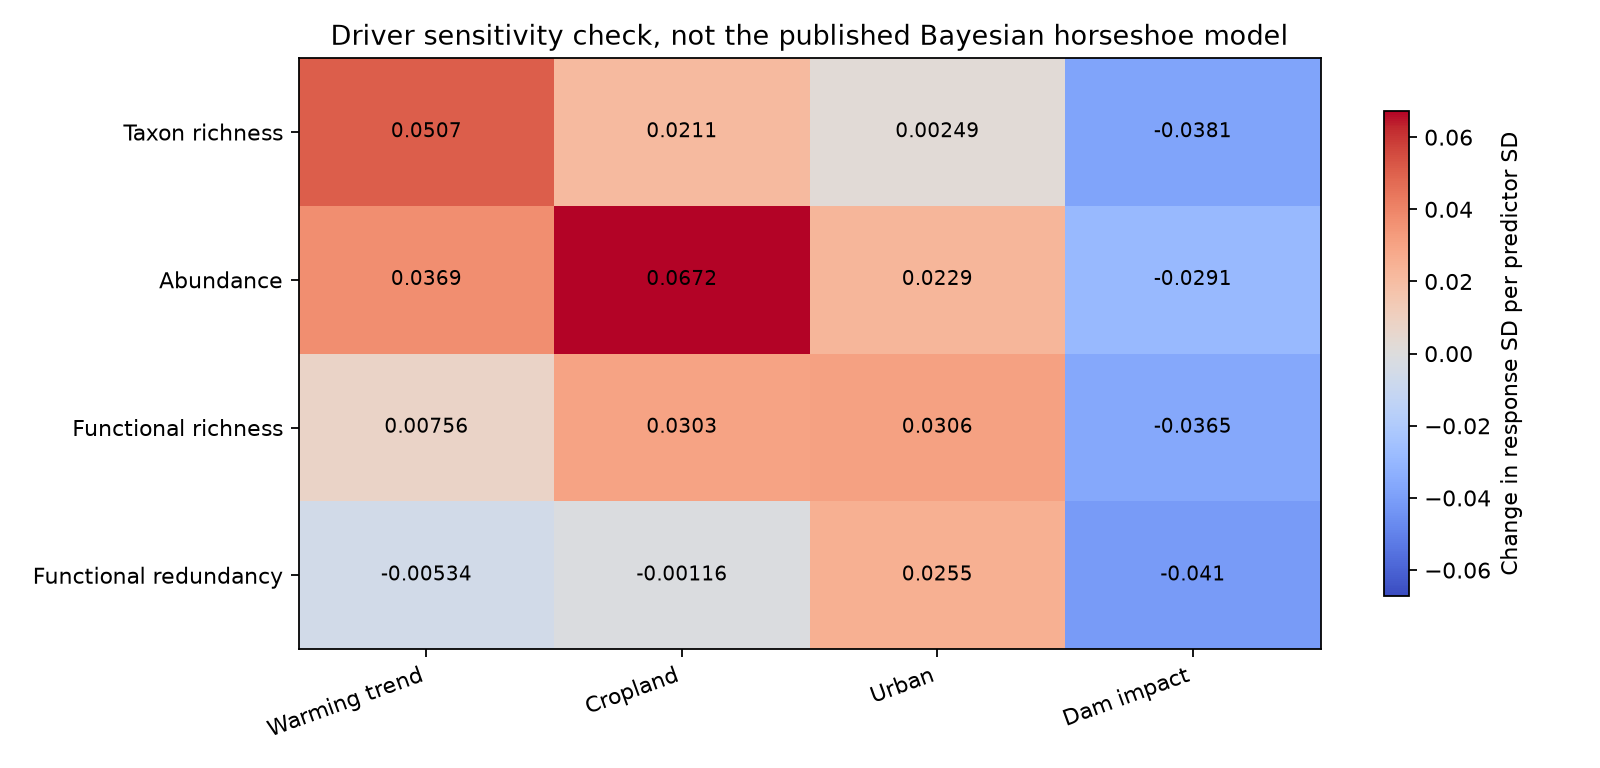

In [ ]:
from pathlib import Path as _AlkNodePath
_alk_node_id = 'haase_drivers'
_alk_metrics_before = dict(globals().get("METRICS", {}))
_alk_artifact_dir = _AlkNodePath("artifacts")
_alk_artifact_dir.mkdir(parents=True, exist_ok=True)
_alk_files_before = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}

print("[[step]] haase_drivers start 5/7 ▶ Driver Sensitivity Check", flush=True)
print("[[title]] haase_drivers Driver Sensitivity Check", flush=True)

import statsmodels.api as sm

# Defined here rather than borrowed from the long-term branch: this node depends
# only on the audit step, so on the canvas it can run in parallel with the
# long-term check and must not assume that branch's variables exist.
driver_specs = {
    "spp_richness": "Taxon richness",
    "abundance": "Abundance",
    "FRic": "Functional richness",
    "FRed": "Functional redundancy",
}

predictors = [
    "ppt_Est", "tmax_Est", "ppt_mm_12moPrior", "tmax_C_12moPrior",
    "strahler_streamOrder", "accumulation_atPoint", "elevation_atPoint",
    "slope_atPoint", "urban_meanPerc_subcatch", "crop_meanPerc_subcatch",
    "dam_impact_score_lessthan100km",
]
driver_rows = []
for response in driver_specs:
    working = df_haase_audit[["study_id", response, *predictors]].dropna().copy()
    x = working[predictors].astype(float)
    x = (x - x.mean()) / x.std(ddof=0)
    response_values = working[response].astype(float)
    response_sd = float(response_values.std(ddof=0))
    standardized_response = (response_values - response_values.mean()) / response_sd
    fitted = sm.OLS(standardized_response, sm.add_constant(x)).fit(
        cov_type="cluster", cov_kwds={"groups": working["study_id"]},
    )
    interval = fitted.conf_int()
    for predictor in predictors:
        driver_rows.append({
            "response": response,
            "predictor": predictor,
            "standardized_effect": float(fitted.params[predictor]),
            "cluster_robust_low_95": float(interval.loc[predictor, 0]),
            "cluster_robust_high_95": float(interval.loc[predictor, 1]),
            "p_value": float(fitted.pvalues[predictor]),
            "response_sd": response_sd,
            "rows": int(len(working)),
            "studies": int(working["study_id"].nunique()),
            "model": "OLS sensitivity with standard errors clustered by study",
        })

driver_results = pd.DataFrame(driver_rows)
driver_results.to_csv(ARTIFACT_DIR / "haase_drivers__clustered_ols.csv", index=False)

focus = ["tmax_Est", "crop_meanPerc_subcatch", "urban_meanPerc_subcatch", "dam_impact_score_lessthan100km"]
matrix = driver_results[driver_results["predictor"].isin(focus)].pivot(
    index="response", columns="predictor", values="standardized_effect",
).reindex(index=list(driver_specs), columns=focus)
scale = float(np.nanmax(np.abs(matrix.to_numpy()))) or 1.0
fig, ax = plt.subplots(figsize=(10, 4.8))
image = ax.imshow(matrix.to_numpy(), cmap="coolwarm", vmin=-scale, vmax=scale, aspect="auto")
ax.set_xticks(range(len(focus)), ["Warming trend", "Cropland", "Urban", "Dam impact"], rotation=20, ha="right")
ax.set_yticks(range(len(driver_specs)), [driver_specs[k] for k in driver_specs])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix.iloc[i, j]:.3g}", ha="center", va="center", fontsize=9)
bar = fig.colorbar(image, ax=ax, shrink=0.82)
bar.set_label("Change in response SD per predictor SD")
ax.set_title("Driver sensitivity check, not the published Bayesian horseshoe model")
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "haase_drivers__sensitivity_heatmap.png", dpi=160)
plt.close(fig)

metrics["haase_drivers::models"] = int(len(driver_specs))
metrics["haase_drivers::predictors"] = int(len(predictors))
metrics["haase_drivers::method"] = "clustered OLS sensitivity, not the published Bayesian horseshoe model"
df_haase_drivers = df_haase_audit
print("[[step]] haase_drivers done 5/7 ✓ Driver Sensitivity Check", flush=True)


_alk_metrics = globals().setdefault("METRICS", {})
for _k, _v in list(_alk_metrics.items()):
    if (_k not in _alk_metrics_before or _alk_metrics_before[_k] != _v) and "::" not in str(_k):
        _alk_metrics[_alk_node_id + "::" + str(_k)] = _v
if "df" in globals() and hasattr(df, "shape"):
    _alk_metrics[_alk_node_id + "::output_rows"] = int(df.shape[0])
    _alk_metrics[_alk_node_id + "::output_columns"] = int(df.shape[1])
_alk_files_after = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}
_alk_changed_files = [
    _name for _name, _stamp in _alk_files_after.items()
    if _alk_files_before.get(_name) != _stamp
]
if not _alk_changed_files and "df" in globals() and hasattr(df, "head"):
    _alk_preview = _alk_artifact_dir / (_alk_node_id + "__result_preview.csv")
    df.head(200).to_csv(_alk_preview, index=False)
    _alk_changed_files = [_alk_preview.name]
_alk_ledger = _AlkNodePath("work/node_artifact_owners.tsv")
_alk_ledger.parent.mkdir(parents=True, exist_ok=True)
with _alk_ledger.open("a", encoding="utf-8") as _alk_owner_file:
    for _name in _alk_changed_files:
        if "__" not in _AlkNodePath(_name).stem and "\t" not in _name and "\n" not in _name:
            _alk_owner_file.write(_alk_node_id + "\t" + _name + "\n")

## Reproduction Boundary

In [ ]:
from pathlib import Path as _AlkNodePath
_alk_node_id = 'haase_scope'
_alk_metrics_before = dict(globals().get("METRICS", {}))
_alk_artifact_dir = _AlkNodePath("artifacts")
_alk_artifact_dir.mkdir(parents=True, exist_ok=True)
_alk_files_before = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}

print("[[step]] haase_scope start 6/7 ▶ Reproduction Boundary", flush=True)
print("[[title]] haase_scope Reproduction Boundary", flush=True)

scope_record = {
    "analysis_unit": "one row per site",
    "rows": int(len(df_haase_audit)),
    "supported": [
        "audit the 1,816 site-level time series and their geographic and temporal coverage",
        "check the direction and magnitude of long-term trend estimates",
        "run an unweighted study-cluster sensitivity analysis of environmental drivers",
    ],
    "not_supported_by_this_file": [
        "recalculate taxonomic or functional diversity from site-by-year community observations",
        "recreate the paper's uncertainty-weighted Bayesian hierarchical estimates because first-stage standard errors are absent",
        "recreate the ten-year moving-window analysis because site-by-year observations and window-specific estimates are absent",
    ],
    "forbidden_substitution": "Starting_year describes when each time series began. It is not an observation year and must not be used to construct moving windows.",
}
with open(ARTIFACT_DIR / "haase_scope__reproduction_boundary.json", "w") as handle:
    json.dump(scope_record, handle, indent=2)
metrics["haase_scope::moving_window_reproducible"] = 0
metrics["haase_scope::weighted_bayesian_reproducible"] = 0
df_haase_scope = df_haase_audit
print("[[step]] haase_scope done 6/7 ✓ Reproduction Boundary", flush=True)


_alk_metrics = globals().setdefault("METRICS", {})
for _k, _v in list(_alk_metrics.items()):
    if (_k not in _alk_metrics_before or _alk_metrics_before[_k] != _v) and "::" not in str(_k):
        _alk_metrics[_alk_node_id + "::" + str(_k)] = _v
if "df" in globals() and hasattr(df, "shape"):
    _alk_metrics[_alk_node_id + "::output_rows"] = int(df.shape[0])
    _alk_metrics[_alk_node_id + "::output_columns"] = int(df.shape[1])
_alk_files_after = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}
_alk_changed_files = [
    _name for _name, _stamp in _alk_files_after.items()
    if _alk_files_before.get(_name) != _stamp
]
if not _alk_changed_files and "df" in globals() and hasattr(df, "head"):
    _alk_preview = _alk_artifact_dir / (_alk_node_id + "__result_preview.csv")
    df.head(200).to_csv(_alk_preview, index=False)
    _alk_changed_files = [_alk_preview.name]
_alk_ledger = _AlkNodePath("work/node_artifact_owners.tsv")
_alk_ledger.parent.mkdir(parents=True, exist_ok=True)
with _alk_ledger.open("a", encoding="utf-8") as _alk_owner_file:
    for _name in _alk_changed_files:
        if "__" not in _AlkNodePath(_name).stem and "\t" not in _name and "\n" not in _name:
            _alk_owner_file.write(_alk_node_id + "\t" + _name + "\n")

## Reproduction Record

In [ ]:
from pathlib import Path as _AlkNodePath
_alk_node_id = 'haase_report'
_alk_metrics_before = dict(globals().get("METRICS", {}))
_alk_artifact_dir = _AlkNodePath("artifacts")
_alk_artifact_dir.mkdir(parents=True, exist_ok=True)
_alk_files_before = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}

print("[[step]] haase_report start 7/7 ▶ Reproduction Record", flush=True)
print("[[title]] haase_report Reproduction Record", flush=True)

record = {
    "study": "Haase et al. (2023), The recovery of European freshwater biodiversity has come to a halt",
    "article_doi": "10.1038/s41586-023-06400-1",
    "data_doi": "10.6084/m9.figshare.22227841",
    "input": {
        "analysis_unit": "site-level annual trend estimate",
        "sites": int(metrics["haase_audit::sites"]),
        "studies": int(metrics["haase_audit::studies"]),
        "countries": int(metrics["haase_audit::countries"]),
        "coverage": [int(metrics["haase_audit::first_year"]), int(metrics["haase_audit::last_year"])],
    },
    "random_seed": 42,
    "bootstrap_resamples": 5000,
    "claims": {
        "long_term_direction_checked": True,
        "published_estimates_inside_study_bootstrap_intervals": {
            row["metric"]: bool(row["paper_estimate_inside_sensitivity_interval"])
            for row in summary_rows
        },
        "moving_window_plateau_reproduced": False,
        "published_bayesian_horseshoe_driver_model_reproduced": False,
    },
    "artifacts": [
        "haase_audit__dataset_audit.csv",
        "haase_audit__trend_missingness.csv",
        "haase_audit__site_map.png",
        "haase_long_term__trend_comparison.csv",
        "haase_long_term__published_comparison.png",
        "haase_distribution__site_trends.png",
        "haase_distribution__summary.csv",
        "haase_drivers__clustered_ols.csv",
        "haase_drivers__sensitivity_heatmap.png",
        "haase_scope__reproduction_boundary.json",
    ],
}
with open(ARTIFACT_DIR / "haase_report__reproduction_record.json", "w") as handle:
    json.dump(record, handle, indent=2)

metrics["haase_report::published_estimates_inside_intervals"] = int(sum(
    bool(row["paper_estimate_inside_sensitivity_interval"]) for row in summary_rows
))
metrics["haase_report::published_estimates_compared"] = int(len(summary_rows))
with open(ARTIFACT_DIR / "metrics.json", "w") as handle:
    json.dump(metrics, handle, indent=2, default=lambda value: value.item() if hasattr(value, "item") else str(value))
print("[[step]] haase_report done 7/7 ✓ Reproduction Record", flush=True)
_alk_metrics = globals().setdefault("METRICS", {})
for _k, _v in list(_alk_metrics.items()):
    if (_k not in _alk_metrics_before or _alk_metrics_before[_k] != _v) and "::" not in str(_k):
        _alk_metrics[_alk_node_id + "::" + str(_k)] = _v
if "df" in globals() and hasattr(df, "shape"):
    _alk_metrics[_alk_node_id + "::output_rows"] = int(df.shape[0])
    _alk_metrics[_alk_node_id + "::output_columns"] = int(df.shape[1])
_alk_files_after = {
    _p.name: (_p.stat().st_mtime_ns, _p.stat().st_size)
    for _p in _alk_artifact_dir.iterdir() if _p.is_file()
}
_alk_changed_files = [
    _name for _name, _stamp in _alk_files_after.items()
    if _alk_files_before.get(_name) != _stamp
]
if not _alk_changed_files and "df" in globals() and hasattr(df, "head"):
    _alk_preview = _alk_artifact_dir / (_alk_node_id + "__result_preview.csv")
    df.head(200).to_csv(_alk_preview, index=False)
    _alk_changed_files = [_alk_preview.name]
_alk_ledger = _AlkNodePath("work/node_artifact_owners.tsv")
_alk_ledger.parent.mkdir(parents=True, exist_ok=True)
with _alk_ledger.open("a", encoding="utf-8") as _alk_owner_file:
    for _name in _alk_changed_files:
        if "__" not in _AlkNodePath(_name).stem and "\t" not in _name and "\n" not in _name:
            _alk_owner_file.write(_alk_node_id + "\t" + _name + "\n")

## Run output

In [ ]:
# captured stdout (tail)

[[step]] n_data start 1/7 ▶ Haase 2023 site-level trends
[[step]] n_data done 1/7 ✓ Haase 2023 site-level trends
[[step]] haase_audit start 2/7 ▶ Audit Site-Level Input
[[title]] haase_audit Audit Site-Level Input
[[step]] haase_audit done 2/7 ✓ Audit Site-Level Input
[[step]] haase_long_term start 3/7 ▶ Long-Term Trend Check
[[title]] haase_long_term Long-Term Trend Check
[[step]] haase_long_term done 3/7 ✓ Long-Term Trend Check
[[step]] haase_distribution start 4/7 ▶ Site Trend Distributions
[[title]] haase_distribution Site Trend Distributions
[[step]] haase_distribution done 4/7 ✓ Site Trend Distributions
[[step]] haase_drivers start 5/7 ▶ Driver Sensitivity Check
[[title]] haase_drivers Driver Sensitivity Check
[[step]] haase_drivers done 5/7 ✓ Driver Sensitivity Check
[[step]] haase_scope start 6/7 ▶ Reproduction Boundary
[[title]] haase_scope Reproduction Boundary
[[step]] haase_scope done 6/7 ✓ Reproduction Boundary
[[step]] haase_report start 7/7 ▶ Reproduction Record
[[title]

## Metrics
```json
{
  "n_data::rows": 1816,
  "n_data::columns": 48,
  "haase_audit::sites": 1816,
  "haase_audit::studies": 47,
  "haase_audit::countries": 22,
  "haase_audit::first_year": 1968,
  "haase_audit::last_year": 2020,
  "haase_long_term::spp_richness_study_balanced_mean": 0.258039227764949,
  "haase_long_term::spp_richness_positive_site_share": 0.6987885462555066,
  "haase_long_term::spp_richness_paper_inside_interval": 1,
  "haase_long_term::abundance_study_balanced_mean": 0.013699116280924115,
  "haase_long_term::abundance_positive_site_share": 0.6095814977973568,
  "haase_long_term::abundance_paper_inside_interval": 1,
  "haase_long_term::FRic_study_balanced_mean": 0.012536733790846232,
  "haase_long_term::FRic_positive_site_share": 0.6685022026431718,
  "haase_long_term::FRic_paper_inside_interval": 1,
  "haase_long_term::FRed_study_balanced_mean": 0.00019571890021298502,
  "haase_long_term::FRed_positive_site_share": 0.5297356828193832,
  "haase_long_term::FRed_paper_inside_interval": 1,
  "haase_distribution::metrics_plotted": 4,
  "haase_drivers::models": 4,
  "haase_drivers::predictors": 11,
  "haase_drivers::method": "clustered OLS sensitivity, not the published Bayesian horseshoe model",
  "haase_scope::moving_window_reproducible": 0,
  "haase_scope::weighted_bayesian_reproducible": 0,
  "haase_report::published_estimates_inside_intervals": 4,
  "haase_report::published_estimates_compared": 4
}
```